# Time Series Forecasting

In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

### 

>Creamos una funcion que usaremos más adelante

In [32]:
def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

## Carga de datos

In [33]:
with open('/workspaces/adamcn10-intro-ml/data/processed/time-series-Xy-train.pkl', 'rb') as file:
    Xy_train = pickle.load(file)

with open('/workspaces/adamcn10-intro-ml/data/processed/time-series-Xy-test.pkl', 'rb') as file:
    Xy_test = pickle.load(file)

df = pd.concat([Xy_train, Xy_test])
df

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633
...,...
2023-08-30 17:10:08.079328,989.600354
2023-08-31 17:10:08.079328,994.987326
2023-09-01 17:10:08.079328,995.814415


## Análisis y graficos

### Análisis visual

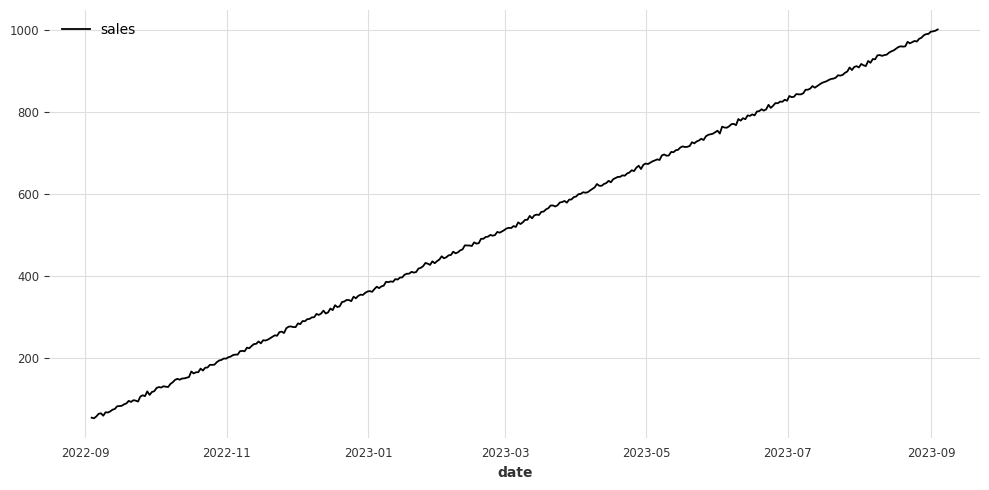

In [34]:
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)

plt.tight_layout()
plt.show()

>Podemos ver a priori que parece que la serie temporal tiene una tendencia positiva lineal, no vemos ninguna estacionalidad clara y en cuanto a variabilidad, puntos atípicvos y puntos de inflexión no podemos ver demasiada cosa clara.

### Análisis de tendencia

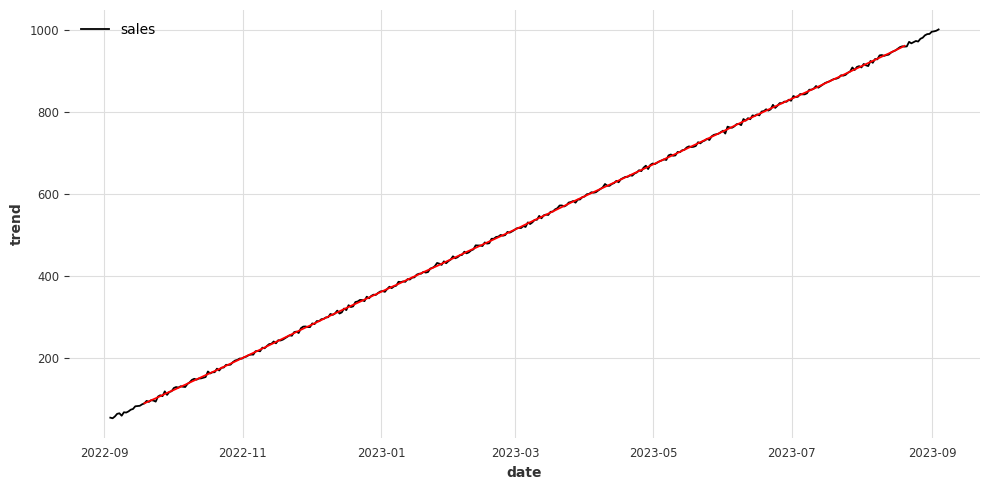

In [35]:
decomposition = seasonal_decompose(df, period = 30)
trend = decomposition.trend
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = trend, c='r')

plt.tight_layout()
plt.show()

>Vemos en rojo claramente una tendencia lineal positiva constante y a lo largo de todo el tiempo estudiado

### Análisis de estacionalidad

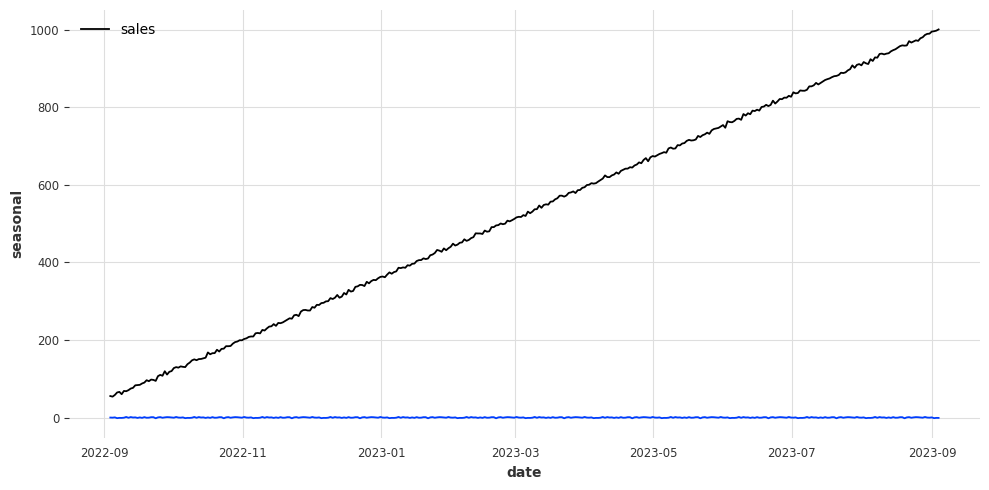

In [36]:
seasonal = decomposition.seasonal
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = seasonal)

plt.tight_layout()
plt.show()

>Al ver la función aplanada cuesta ver estacionalidad, ya que no se aprecian a simple vista las variaciones en esta, parece bastante constante

### Prueba Dickey-Fuller

>Haremos la prueba Dickey-Fuller para comprobar la hipotesis nula de que la serie temporal NO es estacionaria y en el caso de que su p-value sea menor de 0.05 podremos negar la hipotesis nula y afirmar en consecuencia que la serie temporal SI es estacionaria

In [37]:
test_stationarity(df)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

>Podemos ver un p-value mucho mayor al 0.05 que considaramos habitualmente para negar la hipotesis nula, por ello no podemos negar la hipotesis nula de que esta serie temporal no es estacionaría y por ello no la podremos tratar como estacionaria

### Análisis de variabilidad

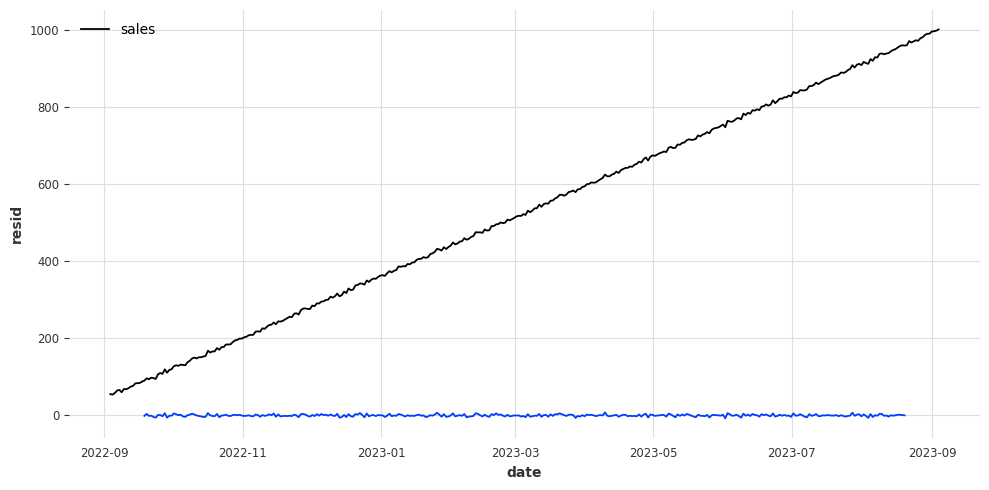

In [38]:
residual = decomposition.resid
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = residual)

plt.tight_layout()
plt.show()

>Al estudiar la tendencia y haber visto que era lineal podiamos llegar anteriormente a la misma conclusión a la que podemos llegar con este análisis y esta es que la variabilidad es bastante constante, de un valor a su posterior hay un aumento muy similar en la mayoría de los elementos de la seria temporal

### Análisis de autocorrelación

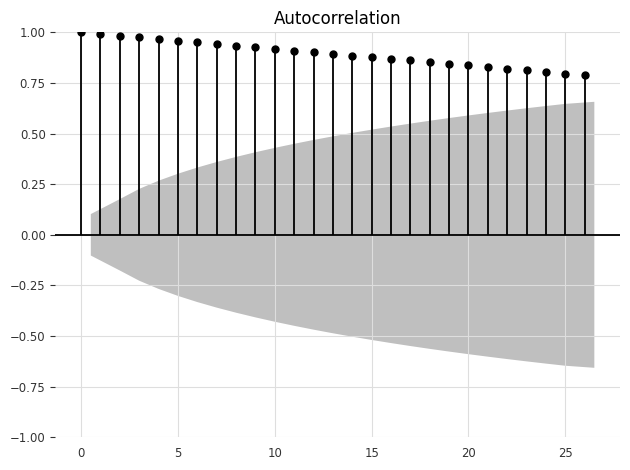

In [39]:
plot_acf(df)
plt.tight_layout()
plt.show()

>Vemos una autocorrelación bastante alta, lo que significa que los valores pueden depender mayoritariamente de los anteriores a estos, pero vemos que cada vez hay una autocorrelación menor y esto puede acabar dificultando una buena predicción de valores futuros.

### Análisis de las diferencias

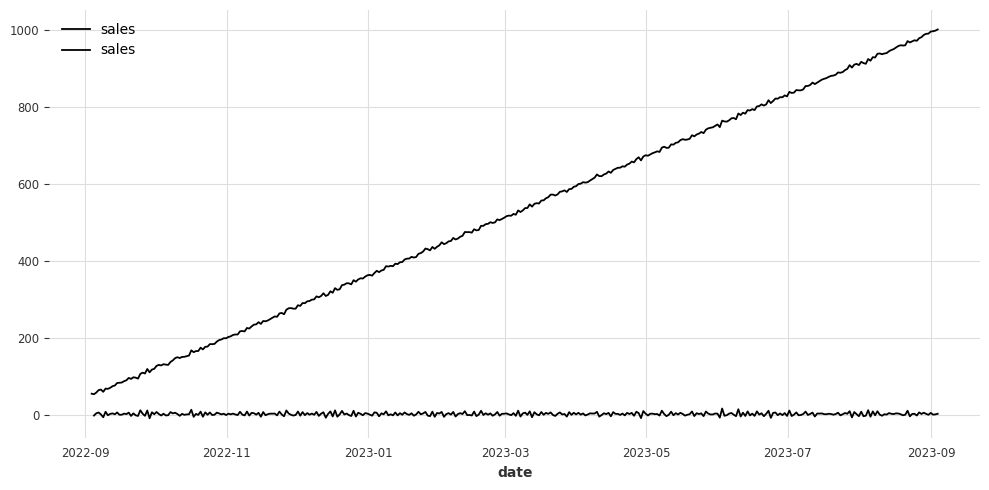

In [40]:
df_diff = df.diff().dropna()
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = df_diff)

plt.tight_layout()
plt.show()

>Vemos como se muestra la gráfica de la función que muestra las diferencias de los elementos de la linea temporal y sus elementos anteriores y analizaremos también si esta si que es estacionaria.

In [41]:
test_stationarity(df_diff)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -9.430263e+00
p-value                        5.212954e-16
#Lags Used                     1.200000e+01
Number of Observations Used    3.520000e+02
Critical Value (1%)           -3.449065e+00
Critical Value (5%)           -2.869786e+00
Critical Value (10%)          -2.571163e+00
dtype: float64

>En este caso el p-value que si que es claramente menor al 0.05 que marcamabos como límite, así que en este caso podemos negar claramente la hipotesis nula que dice que no es estacionaria y por ello podemos afirmar que la función de las diferencias de la serie temporal si que es estacionaría y por tanto podemos aplicar ARIMA sobre esta.

## Modelado y Predicción

>Cómo la serie temporal no es estacionaria pero sus diferencias sí, convertiremos Xy_train y Xy_test en sus versiones de sus diferencias.

In [43]:
Xy_train_diff = Xy_train.diff().dropna()
Xy_test_diff = Xy_test.diff().dropna()

In [55]:
model = ARIMA(Xy_train_diff).fit()
model.summary()

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  sales   No. Observations:                  292
Model:                          ARIMA   Log Likelihood                -839.992
Date:                Sun, 20 Jul 2025   AIC                           1683.985
Time:                        18:44:30   BIC                           1691.338
Sample:                    09-04-2022   HQIC                          1686.930
                         - 06-22-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6083      0.255     10.220      0.000       2.108       3.109
sigma2        18.4584      1.551     11.899      0.000      15.418      21.499
===================================================================================
Ljung-Box (L1) (Q):                  82.54   Jarque-Bera (JB):                 2.87
Prob(Q):                              0.00   Prob(JB):                         0.24
Heteroskedasticity (H):               1.12   Skew:                             0.24
Prob(H) (two-sided):                  0.58   Kurtosis:                         3.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

>Entrenamos el modeo ARIMA con el train splitteado para después probar a predecir el test de 73 elementos como los que quitamos en el Split de eda

In [57]:
forecast = model.predict(73)
forecast

2022-11-16 17:10:08.079328    2.608281
2022-11-17 17:10:08.079328    2.608281
2022-11-18 17:10:08.079328    2.608281
2022-11-19 17:10:08.079328    2.608281
2022-11-20 17:10:08.079328    2.608281
                                ...   
2023-06-18 17:10:08.079328    2.608281
2023-06-19 17:10:08.079328    2.608281
2023-06-20 17:10:08.079328    2.608281
2023-06-21 17:10:08.079328    2.608281
2023-06-22 17:10:08.079328    2.608281
Freq: D, Name: predicted_mean, Length: 219, dtype: float64

In [61]:
Xy_train_diff

,sales
date,
2022-09-04 17:10:08.079328,-1.488946
2022-09-05 17:10:08.079328,4.338482
2022-09-06 17:10:08.079328,6.389205
2022-09-07 17:10:08.079328,1.482734
2022-09-08 17:10:08.079328,-5.931768
...,...
2023-06-18 17:10:08.079328,1.038758
2023-06-19 17:10:08.079328,4.438824
2023-06-20 17:10:08.079328,-3.187062


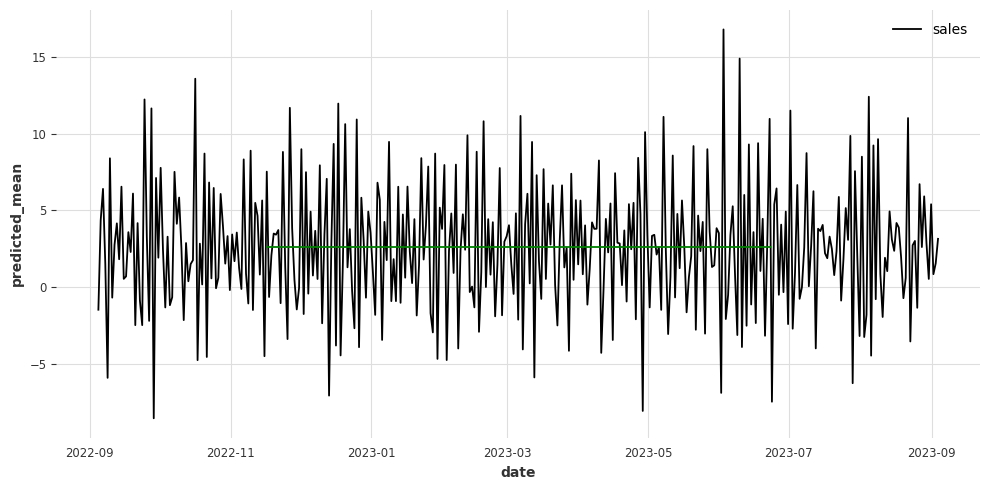

In [58]:
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df_diff)
sns.lineplot(data = forecast, c = "green")

plt.tight_layout()
plt.show()

## Guardado de Modelos